### Binary Traffic Sign Classification

This is our first notebook on neural networks. We will start by building a simple neural network that will help us to classify two types of traffic signs. The signs used in this lesson are a processed subset from the famous German Traffic Sign Recognition Database (GTSRB) that can be downloaded [here]().

In [2]:
import os
import cv2
from time import time
import numpy as np
from sklearn.utils import shuffle

from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 6]

#### Data Loading

Let's now load the data to see what we are dealing with.

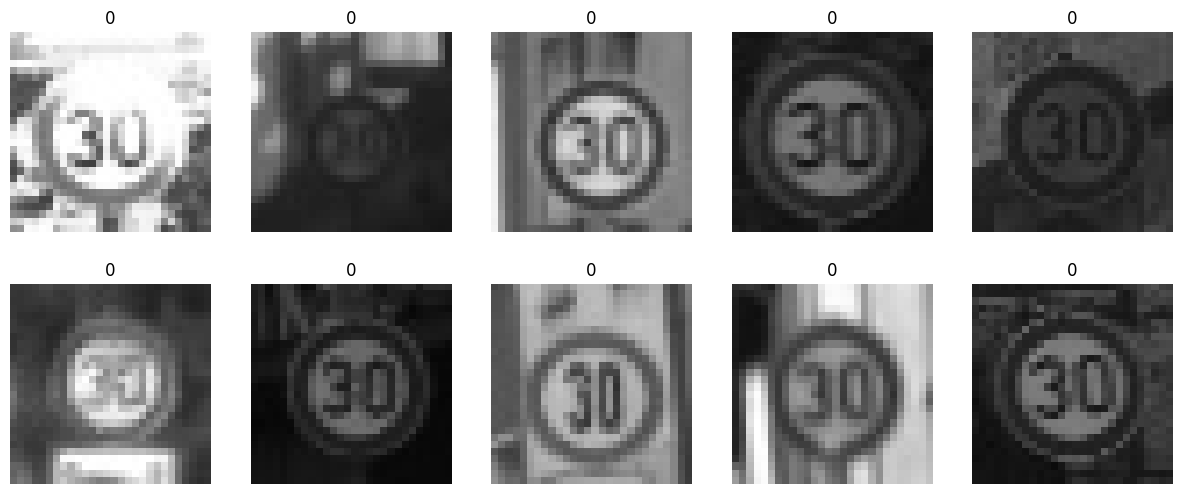

In [4]:
folder = '../data/subset_homework'

# Load traffic sign class 0
fnames_0 = os.listdir(os.path.join(folder, 'class_id_0'))
images_0 = [cv2.imread(os.path.join(folder, 'class_id_0', f), cv2.IMREAD_UNCHANGED) for f in fnames_0]
labels_0 = [0] * len(images_0)

for cnt, idx in enumerate(np.random.randint(0, len(images_0), 10)):
    plt.subplot(2,5,cnt+1)
    plt.imshow(images_0[idx], cmap='gray', vmin=0, vmax=255)
    plt.title(labels_0[idx]), plt.axis(False)

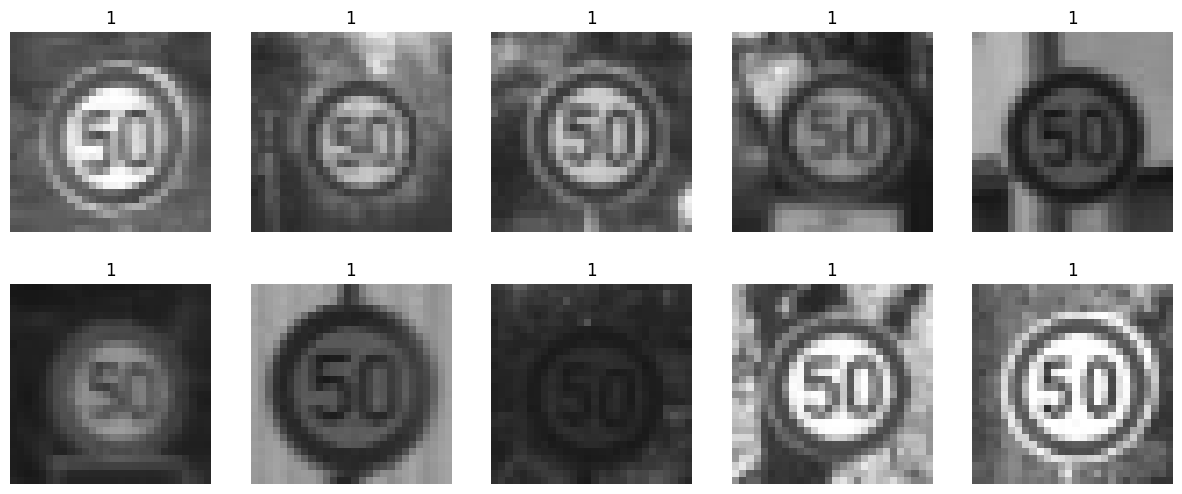

In [7]:
# Load traffic sign class 1
fnames_1 = os.listdir(os.path.join(folder, 'class_id_1'))
images_1 = [cv2.imread(os.path.join(folder, 'class_id_1', f), cv2.IMREAD_UNCHANGED) for f in fnames_1]
labels_1 = [1] * len(images_1)

for cnt, idx in enumerate(np.random.randint(0, len(images_1), 10)):
    plt.subplot(2,5,cnt+1)
    plt.imshow(images_1[idx], cmap='gray', vmin=0, vmax=255)
    plt.title(labels_1[idx]), plt.axis(False)

In [9]:
print('Num samples class_0', len(images_0))
print('Num samples class_1', len(images_1))

Num samples class_0 2220
Num samples class_1 2250


#### Prepare Input Data

To train our neural network model, we have to prepare the data to the format the the model actually expects. In our case, this will be numpy arrays.

In [12]:
# Put both classes together and shuffle the data
images = images_0 + images_1
labels = labels_0 + labels_1
images, labels = shuffle(images, labels)

images = np.array(images)
labels = np.array(labels)

print('Images', images.shape)
print('Labels', labels.shape)

Images (4470, 28, 28)
Labels (4470,)


But now we have a problem. We cannot just feed the image to a neuron since the neuron inputs are flat (one dimensional). On the other hand, the images are 2D matrices. Therefore, we need to "flatten" the images to a one dimensional vector of pixels.

In [15]:
start = time()
pixels = []
for image in images:
    pixels_ = []
    for r in range(image.shape[0]):
        for c in range(image.shape[1]):
            pixels_.append(image[r,c])
    pixels.append(pixels_)
    
pixels = np.array(pixels)/255
stop = time()

print('Shape', pixels.shape)
print('Elapsed time', stop - start)

Shape (4470, 784)
Elapsed time 0.9371140003204346


Or, you know, just let make use of our friend numpy :-)

In [18]:
start = time()
pixels = np.array([image.flatten() for image in images])/255
stop = time()

print('Shape', pixels.shape)
print('Elapsed time', stop - start)

Shape (4470, 784)
Elapsed time 0.04149794578552246


Before the training, let's again have a look at some raqndom samples from our dataset.

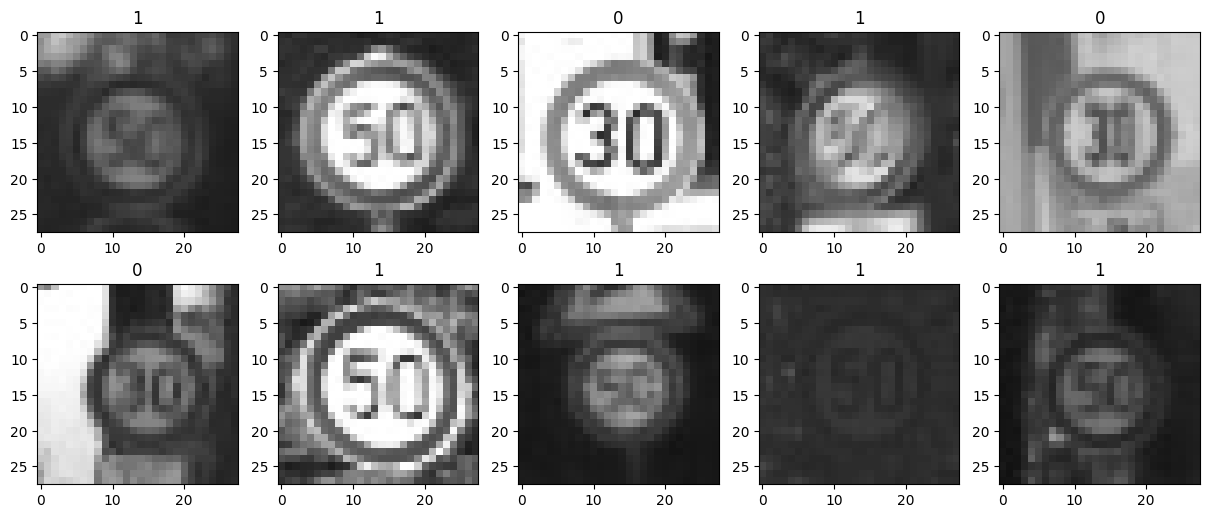

In [21]:
for cnt, idx in enumerate(np.random.randint(0, len(images), 10)):    
    plt.subplot(2,5,cnt+1)
    plt.imshow(images[idx], cmap='gray', vmin=0, vmax=255)
    plt.title(labels[idx])

#### Building the Neural Network

Let's now build our first (and yes, very simple) neural network using Tensorflow. For that, we will need a couple of new imports.

In [28]:
import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import Dense, Input, Dropout

The following netowork will consist of only one single neuron. It is a very tiny network (not even a network, strictly speaking :-) ) and yet it can be quite powerful.

Додавання прихованих шарів (hidden layers) у нейронну мережу впливає на її здатність навчатися складнішим залежностям у даних.
1. Здатність моделі вивчати складні закономірності. Без прихованих шарів модель — це просто лінійна регресія, яка може знайти лише пряму лінійну залежність між ознаками та результатом. З прихованими шарами мережа може моделювати нелінійні залежності — тобто виявляти складні патерни (вигини, криві, комбіновані ефекти різних змінних) та зв’язки, які не можна описати простою прямою лінією.
2. Гнучкість та потужність моделі. Більше шарів = більше нейронів = вища ємність моделі.
3. Швидкість і складність навчання. Чим більше шарів, тим довше тренується модель. Але потрібно більше даних та ресурсів. Може бути складніше підібрати оптимальні параметри (learning rate, регуляризація)
4. Узагальнення та точність. Правильно підібрана глибина мережі дає кращу точність на тестових даних, бо модель краще узагальнює закономірності. Занадто проста модель — недонавчиться (underfitting). Занадто складна — перенавчиться (overfitting).

In [59]:
inputs = Input(shape=(pixels.shape[1],))
x = Dense(128, activation="relu")(inputs)
x = Dense(64, activation="relu")(x)
outputs = Dense(1, activation="linear")(x)
model = Model(inputs, outputs)

#relu — популярна активація для прихованих шарів.
#128 і 64 — кількість нейронів у шарах (можна підбирати).

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 108,801 (425.00 KB)

 Trainable params: 108,801 (425.00 KB)

 Non-trainable params: 0 (0.00 B)

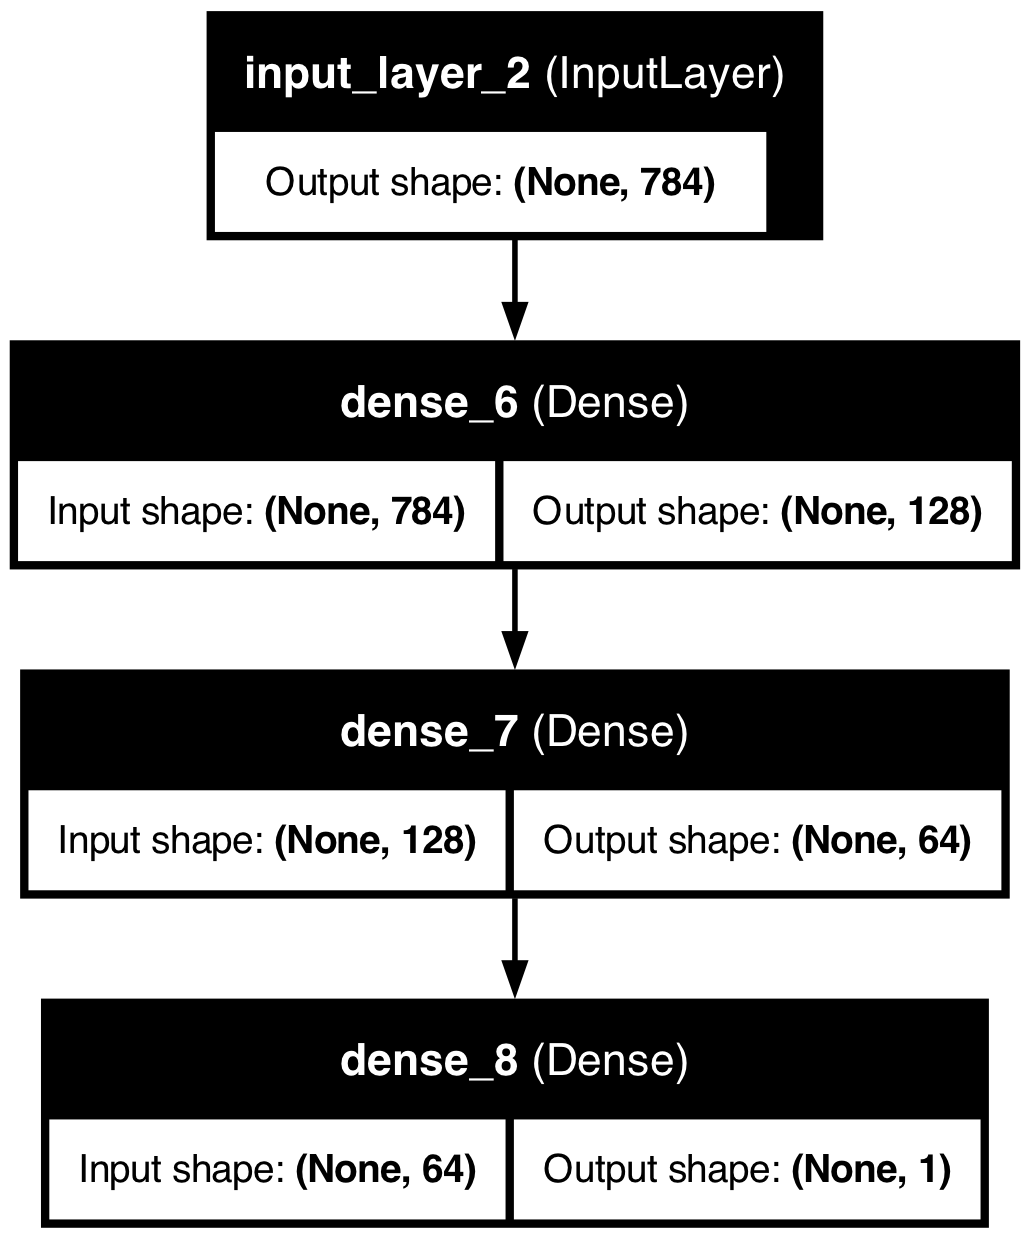

In [61]:
tf.keras.utils.plot_model(model, to_file="model_homework_v2.png", show_shapes=True, show_layer_names=True)

Before starting the training, we have to compile the model. During the compilation, we indicate what optimizer we want to use and what loss should be applied for the minimization process.

In [64]:
model.compile(optimizer ='adam', loss = 'mean_squared_error')

And let's train :-)

In [67]:
history = model.fit(pixels, labels, epochs=10, batch_size=32)

Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2582
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1381
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1170
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0952
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0828
Epoch 6/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0953
Epoch 7/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0759
Epoch 8/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0700
Epoch 9/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0603
Epoch 10/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0615


(Text(0.5, 0, 'epoch'), Text(0, 0.5, 'loss'))

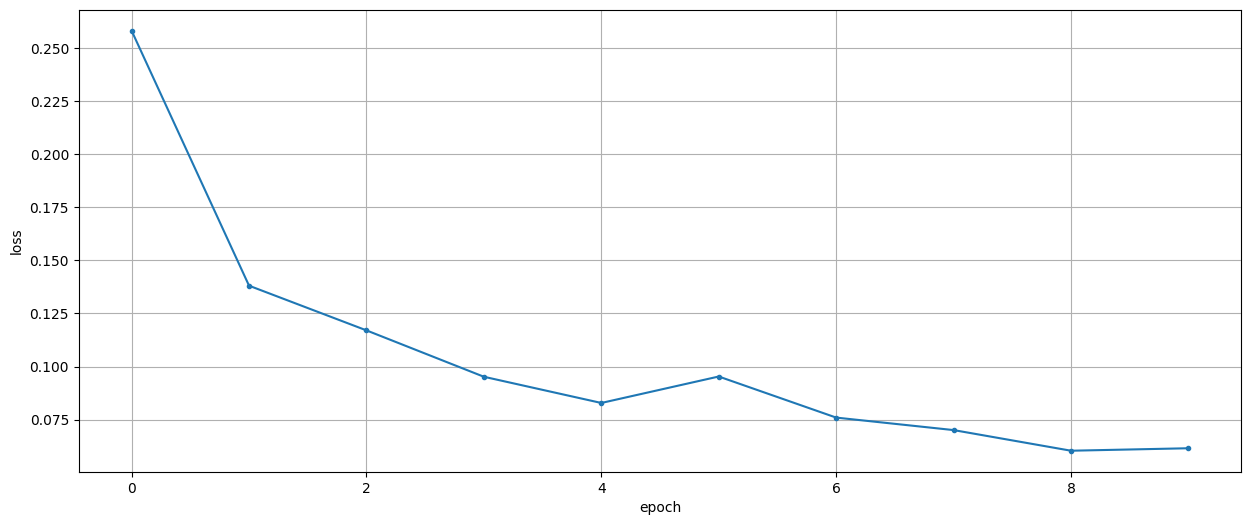

In [69]:
# Plot training history
h = history.history
epochs = range(len(h['loss']))
plt.plot(epochs, h['loss'], '.-'), plt.grid(True)
plt.xlabel('epoch'), plt.ylabel('loss')

[-0.04494159 -0.00597068 -0.00378946 -0.00563263  0.194054    0.1128823
  0.04832041 -0.00600182 -0.00577542 -0.00764974  0.         -0.00372162
 -0.00269542  0.0410537  -0.00431914 -0.00543865 -0.06256159 -0.00600446
 -0.0549176  -0.00442918 -0.06954013 -0.00508985  0.11262789 -0.00377895
  0.07965345 -0.00928387 -0.00314182 -0.00517871  0.1840144  -0.08243322
 -0.01155136 -0.00847566  0.05423669 -0.0569061   0.00218836  0.12350011
 -0.00479252 -0.00462002  0.12652537  0.06158483  0.01307349 -0.00517753
  0.0424867  -0.00386559 -0.0335856  -0.00536451 -0.00540126 -0.07876006
 -0.00649147 -0.00518461  0.0085492  -0.00158157  0.08383647 -0.00481961
 -0.00509624 -0.00658788 -0.0093596  -0.00555569 -0.00860492 -0.00695735
 -0.00515185 -0.07497296  0.02549503 -0.00577608  0.01220962 -0.00874349
 -0.00580642 -0.00599359  0.00531672 -0.00590716 -0.0097527  -0.0065597
 -0.03721598 -0.00938208  0.15054496  0.02013606 -0.00504183 -0.00444076
 -0.00600468 -0.00716721 -0.00671736 -0.00363064 -0.0

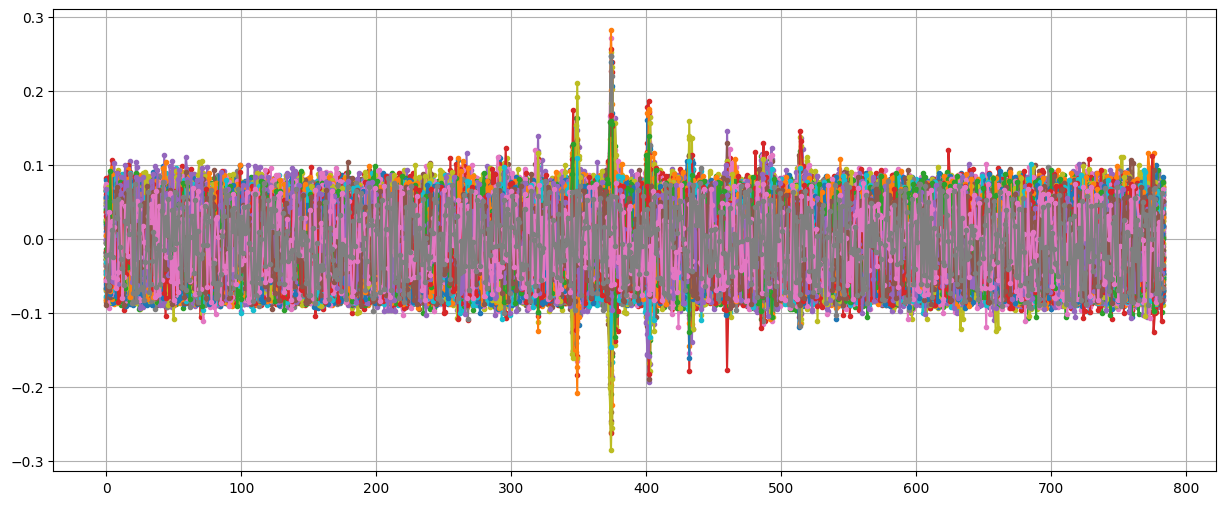

In [71]:
# Let's also have a looks at the learnt weights
plt.plot(model.layers[1].weights[0].numpy(), '.-'), plt.grid(True)
print(model.layers[1].weights[1].numpy(), model.layers[1].bias.numpy())

Кількість нейронів: 128
Мінімальне значення: -0.085929476
Максимальне значення: 0.19713669
Середнє значення: 0.00928006
Стандартне відхилення: 0.051419087


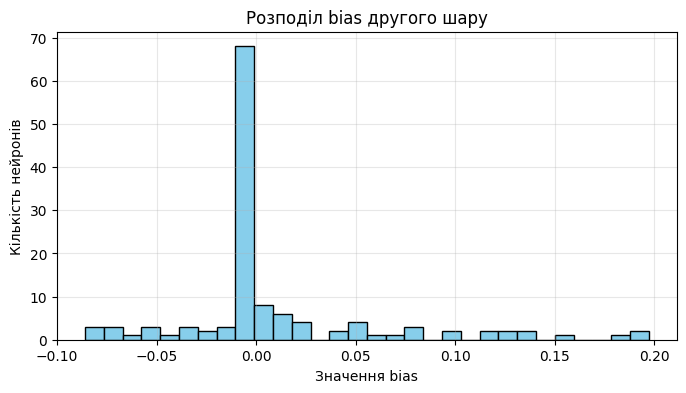

In [73]:
bias = model.layers[1].bias.numpy()

# 📊 Статистика
print("Кількість нейронів:", len(bias))
print("Мінімальне значення:", np.min(bias))
print("Максимальне значення:", np.max(bias))
print("Середнє значення:", np.mean(bias))
print("Стандартне відхилення:", np.std(bias))

# 📈 Побудова гістограми
plt.figure(figsize=(8,4))
plt.hist(bias, bins=30, color='skyblue', edgecolor='black')
plt.title("Розподіл bias другого шару")
plt.xlabel("Значення bias")
plt.ylabel("Кількість нейронів")
plt.grid(True, alpha=0.3)
plt.show()

1. Результат - розподіл bias рівномірний, без великих перекосів. 
2. Значення в межах приблизно [-0.09, 0.2] — це безпечний діапазон.
3. Середнє значення приблизно 0 - немає системного зсуву вгору чи вниз

як можуть виглядаи “погані” значення bias:
1. Наприклад: bias = ±5, ±10, або ще більше - це ознака нестабільного навчання
2. Всі bias дуже близькі до нуля (bias ≈ ±1e-5) - модель не змогла знайти зсуви, які допомагають кращій активації нейронів
3. Сильний перекіс розподілу bias (всі bias > 0.5 або всі < −0.5, середнє далеко від 0) - шар має системний зсув в активації нейронів
4. Великий розкид (σ ≈ 1 або більше, одні нейрони мають bias = 1.5, інші −1.8) - Розбіжність у роботі нейронів → нестабільне навчання

#### Performance Evaluation

Once our model is trained, we will can run it on our images to see how it performs (inference).

In [78]:
idx = 14
pred = model.predict(pixels[idx:idx+1, ...])
print(pred, labels[idx])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
[[0.03120142]] 0


In [80]:
# Run it on the entire dataset
predictions = model.predict(pixels).squeeze()
predictions = predictions > 0.5

140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 901us/step


In [82]:
correct = 0
for prediction, label in zip(predictions, labels):
    if prediction == label:
        correct = correct + 1

print('Accuracy', correct/len(labels))

Accuracy 0.9680089485458613


Збільшення hidden layers та кількість нейронів у шарах підвищую Accuracy

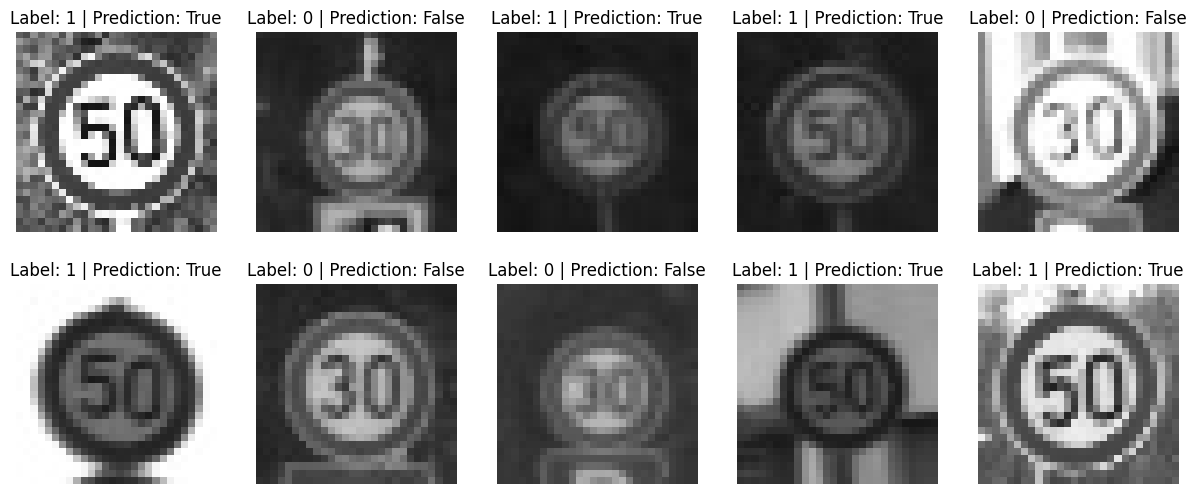

In [56]:
for cnt, idx in enumerate(np.random.randint(0, len(images), 10)): 
    plt.subplot(2,5,cnt+1), plt.imshow(images[idx], cmap='gray', vmin=0, vmax=255)
    plt.title('Label: ' + str(labels[idx]) + ' | Prediction: ' + str(predictions[idx]))
    plt.axis(False)